<div>

# Assignment 4 Eran Rehani 207823063 
# White Dwarf Structure

Newton solver for a system of nonlinear equations. 
Finite-difference hydrostatic-equilibrium equations for a white dwarf, and a wrapper that finds the stellar structure from an initial radius guess.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

G = 6.67430e-8          # cm^3 g^-1 s^-2
M_SUN = 2.0e33         # g
R_SUN = 7.0e10         # cm
KAPPA_NON_REL = 3.15e12
KAPPA_REL = 4.9e14

<div>


## Multidimensional Newton Solver

`newton_nd` solves $F(x)=0$ using the linear Newton correction
$J(x)d=-F(x)$. `accept_step` is optional callback and it is used later to keep the white-dwarf shell radii ordered and positive.

</div>

In [2]:
def newton_nd(F, J, x0, tol_f=1e-10, tol_x=1e-10, max_iter=50,
              accept_step=None, verbose=False):
    """Solve F(x)=0 for a vector x using Newton's method.

    Parameters
    ----------
    F, J : callable
        F(x) returns the residual vector and J(x) returns the Jacobian matrix.
    x0 : array_like
        Initial guess.
    accept_step : callable, optional
        Function accept_step(x, dx) returning a damping factor in (0, 1].
    """
    x = np.asarray(x0, dtype=float).copy()
    history = []

    for iteration in range(max_iter):
        fx = np.asarray(F(x), dtype=float)
        residual_norm = np.linalg.norm(fx, ord=np.inf)
        history.append(residual_norm)

        if verbose:
            print(f"iter={iteration:2d}, |F|_inf={residual_norm:.3e}")
        if residual_norm < tol_f:
            return x, {"converged": True, "iterations": iteration, "history": history}

        jac = np.asarray(J(x), dtype=float)
        dx = np.linalg.solve(jac, -fx)
        factor = 1.0 if accept_step is None else float(accept_step(x, dx))
        if not (0.0 < factor <= 1.0):
            raise ValueError("accept_step must return a factor in (0, 1].")

        x_new = x + factor * dx
        step_norm = np.linalg.norm(factor * dx, ord=np.inf)
        x_scale = max(1.0, np.linalg.norm(x_new, ord=np.inf))
        x = x_new

        if step_norm < tol_x * x_scale:
            fx = np.asarray(F(x), dtype=float)
            residual_norm = np.linalg.norm(fx, ord=np.inf)
            history.append(residual_norm)
            return x, {"converged": residual_norm < tol_f, "iterations": iteration + 1,
                       "history": history}

    return x, {"converged": False, "iterations": max_iter, "history": history}



This function implements multi-dimensional Newton’s method to solve $F(x)=0$ for a vector $x$. It starts from `x0`, converts it to a float NumPy array, and iteratively improves the estimate. At each iteration, it computes the residual vector `fx = F(x)` and tracks its infinity norm $\|F(x)\|_\infty$ in `history`.

Convergence is checked first by residual size: if $\|F(x)\|_\infty < \text{tol\_f}$, it returns immediately with `converged=True`. Otherwise, it evaluates the Jacobian `J(x)`, solves the linear Newton system $J(x)\,\Delta x = -F(x)$, and gets the update direction `dx` via `np.linalg.solve`.

The update can be damped using `accept_step(x, dx)`, which must return a factor in $(0,1]$. 
If no callback is given, full Newton step (`factor=1`) is used. The new point is $ x_{\text{new}} = x + \text{factor}\cdot \Delta x $.

A second stopping test checks step size: if $\|\text{factor}\cdot\Delta x\|_\infty < \text{tol\_x}\cdot \max(1,\|x_{\text{new}}\|_\infty)$, it performs one final residual check and returns. This prevents unnecessary iterations when updates become tiny.

Return value is `(x, info_dict)`, where `info_dict` contains `converged`, `iterations`, and residual `history`. If `max_iter` is reached, it returns the last iterate with `converged=False`. Potential failure points are singular/ill-conditioned Jacobians (`np.linalg.solve`).

<div>

### Simple Check

The system below has the exact solution $(x,y)=(1,2)$.

</div>

In [3]:
def F_test(v):
    x, y = v
    return np.array([x**2 + y - 3.0, x + y**2 - 5.0])

def J_test(v):
    x, y = v
    return np.array([[2.0*x, 1.0], [1.0, 2.0*y]])

root_test, info_test = newton_nd(F_test, J_test, [0.8, 1.8])
print(root_test)
print(info_test)

[1. 2.]
{'converged': True, 'iterations': 4, 'history': [np.float64(0.96), np.float64(0.04921686321587426), np.float64(0.0004659653192562452), np.float64(6.889090853334778e-08), np.float64(1.7763568394002505e-15)]}


<div>

## White-Dwarf Residual and Jacobian

The unknowns are the radii $r_i$ at the outer edge of each mass shell. The mass grid is fixed by $m_i=iM/n$. Pressures are evaluated at shell centers from the shell-averaged density,
$\rho_i=(m_i-m_{i-1})/[4\pi(r_i^3-r_{i-1}^3)/3]$ and $p_i=\kappa\rho_i^\gamma$.

</div>

In [4]:
def default_kappa(gamma):
    """Choose the kappa value """
    return KAPPA_NON_REL if gamma > 1.5 else KAPPA_REL

def mass_grid(n, total_mass):
    """Return m_0,...,m_n """
    return np.linspace(0.0, total_mass, n + 1)

def shell_density(r, total_mass):
    """Return the average density in each shell for radii r_1,...,r_n."""
    r = np.asarray(r, dtype=float)
    n = len(r)
    radii = np.concatenate(([0.0], r))
    dm = total_mass / n
    volumes = (4.0 * np.pi / 3.0) * np.diff(radii**3)
    if np.any(volumes <= 0.0):
        raise ValueError("Radii must be positive and strictly increasing.")
    return dm / volumes

def shell_pressure(r, total_mass, gamma, kappa=None):
    """Return p_1,...,p_n from the polytropic equation of state."""
    if kappa is None:
        kappa = default_kappa(gamma)
    rho = shell_density(r, total_mass)
    return kappa * rho**gamma

def white_dwarf_residual(r, total_mass, gamma, kappa=None):
    """Return f_i for the finite-difference hydrostatic-equilibrium equations."""
    r = np.asarray(r, dtype=float)
    n = len(r)
    m = mass_grid(n, total_mass)
    p = shell_pressure(r, total_mass, gamma, kappa)
    p_ext = np.concatenate((p, [0.0]))
    m_ext = np.concatenate((m, [total_mass]))

    f = np.empty(n)
    for i in range(1, n + 1):
        delta_p = p_ext[i] - p_ext[i - 1]
        delta_m = 0.5 * (m_ext[i + 1] - m_ext[i - 1])
        gravity = G * m[i] / (4.0 * np.pi * r[i - 1]**4)
        f[i - 1] = delta_p / delta_m + gravity
    return f

def white_dwarf_jacobian(r, total_mass, gamma, kappa=None):
    """Analytic Jacobian d f_i / d r_j for white_dwarf_residual."""
    r = np.asarray(r, dtype=float)
    n = len(r)
    m = mass_grid(n, total_mass)
    m_ext = np.concatenate((m, [total_mass]))
    radii = np.concatenate(([0.0], r))
    p = shell_pressure(r, total_mass, gamma, kappa)

    # dp[k]/dr[j], with k and j in zero-based indexing for p_1,...,p_n and r_1,...,r_n.
    dp = np.zeros((n, n))
    for k in range(n):
        denom = radii[k + 1]**3 - radii[k]**3
        dp[k, k] += -3.0 * gamma * p[k] * radii[k + 1]**2 / denom
        if k > 0:
            dp[k, k - 1] += 3.0 * gamma * p[k] * radii[k]**2 / denom

    jac = np.zeros((n, n))
    for i in range(1, n + 1):
        delta_m = 0.5 * (m_ext[i + 1] - m_ext[i - 1])
        row = i - 1
        if i < n:
            jac[row, :] += dp[i, :] / delta_m
        jac[row, :] -= dp[i - 1, :] / delta_m
        jac[row, row] += -4.0 * G * m[i] / (4.0 * np.pi * r[row]**5)
    return jac

def hydrostatic_gravity_term(r, total_mass):
    """Return G m_i/(4*pi*r_i^4), the positive gravity term in f_i."""
    r = np.asarray(r, dtype=float)
    n = len(r)
    m = mass_grid(n, total_mass)[1:]
    return G * m / (4.0 * np.pi * r**4)

def white_dwarf_scaled_residual(r, total_mass, gamma, kappa=None):
    """Dimensionless residual with the same roots as white_dwarf_residual."""
    return white_dwarf_residual(r, total_mass, gamma, kappa) / hydrostatic_gravity_term(r, total_mass)

def white_dwarf_scaled_jacobian(r, total_mass, gamma, kappa=None):
    """Jacobian of white_dwarf_scaled_residual."""
    r = np.asarray(r, dtype=float)
    raw = white_dwarf_residual(r, total_mass, gamma, kappa)
    raw_jac = white_dwarf_jacobian(r, total_mass, gamma, kappa)
    gravity = hydrostatic_gravity_term(r, total_mass)
    scaled_jac = raw_jac / gravity[:, None]
    rows = np.arange(len(r))
    scaled_jac[rows, rows] += 4.0 * raw / (gravity * r)
    return scaled_jac

<div>

Finite-difference check is useful because most mistakes in this exercise are sign or indexing mistakes in the Jacobian.

</div>

In [5]:
def check_white_dwarf_jacobian(n=6, mass_solar=1.0, radius_solar=0.02, gamma=5/3):
    total_mass = mass_solar * M_SUN
    r = np.linspace(radius_solar * R_SUN / n, radius_solar * R_SUN, n)
    analytic = white_dwarf_jacobian(r, total_mass, gamma)
    numeric = np.zeros_like(analytic)
    for j in range(n):
        h = 1e-6 * max(abs(r[j]), 1.0)
        step = np.zeros(n)
        step[j] = h
        numeric[:, j] = (white_dwarf_residual(r + step, total_mass, gamma)
                         - white_dwarf_residual(r - step, total_mass, gamma)) / (2.0 * h)
    rel_err = np.linalg.norm(analytic - numeric) / np.linalg.norm(numeric)
    return rel_err

print(check_white_dwarf_jacobian())

5.2949740721391115e-11


<div>

## White-Dwarf Structure Solver

`white_dwarf_structure` receives the parameters in solar units, converts to cgs, and returns the radii, densities, pressures, and convergence information. The damping factor prevents inverted shells during Newton updates.

</div>

In [6]:
def monotonic_radius_step_factor(r, dr, min_fraction=1e-6):
    """Largest damping factor that keeps all shell widths positive."""
    radii = np.concatenate(([0.0], np.asarray(r, dtype=float)))
    delta = np.concatenate(([0.0], np.asarray(dr, dtype=float)))
    widths = np.diff(radii)
    dwidths = np.diff(delta)
    min_width = min_fraction * np.max(radii[1:])

    factor = 1.0
    for width, dwidth in zip(widths, dwidths):
        if width + factor * dwidth <= min_width and dwidth < 0.0:
            factor = min(factor, 0.9 * (width - min_width) / (-dwidth))
    if r[0] + factor * dr[0] <= min_width and dr[0] < 0.0:
        factor = min(factor, 0.9 * (r[0] - min_width) / (-dr[0]))
    return max(factor, 1e-6)

def white_dwarf_structure(n, mass_solar, radius_guess_solar, gamma,
                          kappa=None, tol_f=1e-7, tol_x=1e-10,
                          max_iter=80, verbose=False):
    """Solve the white-dwarf structure equations.

    Parameters are the same as in the exercise: n shells, mass in solar masses,
    initial outer-radius guess in solar radii, and gamma for the equation of state.
    """
    total_mass = mass_solar * M_SUN
    radius_guess = radius_guess_solar * R_SUN
    if kappa is None:
        kappa = default_kappa(gamma)

    r0 = np.linspace(radius_guess / n, radius_guess, n)
    F = lambda r: white_dwarf_scaled_residual(r, total_mass, gamma, kappa)
    J = lambda r: white_dwarf_scaled_jacobian(r, total_mass, gamma, kappa)
    accept = lambda r, dr: monotonic_radius_step_factor(r, dr)
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        r, info = newton_nd(F, J, r0, tol_f=tol_f, tol_x=tol_x,
                            max_iter=max_iter, accept_step=accept, verbose=verbose)

    rho = shell_density(r, total_mass)
    p = shell_pressure(r, total_mass, gamma, kappa)
    return {
        "r": r,
        "r_solar": r / R_SUN,
        "rho": rho,
        "p": p,
        "mass_grid": mass_grid(n, total_mass),
        "outer_radius_cm": r[-1],
        "outer_radius_solar": r[-1] / R_SUN,
        "info": info,
        "gamma": gamma,
        "kappa": kappa,
        "mass_solar": mass_solar,
    }

def structure_table(solution):
    """Return a table with radius and density in cgs units."""
    return [
        {
            "i": i,
            "r_cm": r_cm,
            "r_Rsun": r_solar,
            "rho_g_cm3": rho,
            "p_dyn_cm2": p,
        }
        for i, (r_cm, r_solar, rho, p) in enumerate(
            zip(solution["r"], solution["r_solar"], solution["rho"], solution["p"]),
            start=1,
        )
    ]

<div>


##  Helpers for Tables, Plots, and SciPy Comparison

The cells below are ready to run for the numerical tables requested in the exercise. They are separated from the function definitions so the functions can be imported or tested without running all plots.

</div>

In [7]:
def solve_with_scipy(n, mass_solar, radius_guess_solar, gamma, kappa=None):
    """Solve the same white-dwarf system with scipy.optimize.root."""
    total_mass = mass_solar * M_SUN
    radius_guess = radius_guess_solar * R_SUN
    if kappa is None:
        kappa = default_kappa(gamma)
    widths0 = np.full(n, radius_guess / n)
    y0 = np.log(widths0)

    def radii_from_y(y):
        return np.cumsum(np.exp(y))

    def residual_y(y):
        return white_dwarf_scaled_residual(radii_from_y(y), total_mass, gamma, kappa)

    def jacobian_y(y):
        widths = np.exp(y)
        dr_dy = np.tril(np.ones((n, n))) * widths
        return white_dwarf_scaled_jacobian(radii_from_y(y), total_mass, gamma, kappa) @ dr_dy

    result = optimize.root(
        residual_y,
        y0,
        jac=jacobian_y,
        method="hybr",
    )
    result.r = radii_from_y(result.x)
    result.r_solar = result.r / R_SUN
    return result

def radius_mass_scan(masses, n=100, radius_guess_solar=1.0, gamma=5/3):
    rows = []
    for mass in masses:
        sol = white_dwarf_structure(n, mass, radius_guess_solar, gamma)
        rows.append({
            "M_Msun": mass,
            "R_Rsun": sol["outer_radius_solar"],
            "M13_R": mass**(1/3) * sol["outer_radius_solar"],
            "converged": sol["info"]["converged"],
            "iterations": sol["info"]["iterations"],
            "final_residual": sol["info"]["history"][-1],
        })
    return rows

def plot_density_profile(solution):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(solution["r"], solution["rho"], marker="o", ms=3)
    ax.set_xlabel("r [cm]")
    ax.set_ylabel(r"$\rho$ [g cm$^{-3}$]")
    ax.grid(True, alpha=0.3)
    return fig, ax

0.012197249918625216 {'converged': True, 'iterations': 13, 'history': [np.float64(1.755695432455973), np.float64(6.14073050050806), np.float64(168.5243161001698), np.float64(195.25795551102854), np.float64(140.0025996345673), np.float64(84.11122233933028), np.float64(40.307276080653075), np.float64(18.331645343401203), np.float64(7.455517041254072), np.float64(2.1721462637193425), np.float64(0.253164256449882), np.float64(0.0039003099289909083), np.float64(9.503077999011873e-07), np.float64(1.1117683485825156e-12)]}


[{'i': 1,
  'r_cm': np.float64(105860299.11055744),
  'r_Rsun': np.float64(0.0015122899872936776),
  'rho_g_cm3': np.float64(4024778.979152097),
  'p_dyn_cm2': np.float64(3.207849223557123e+23)},
 {'i': 2,
  'r_cm': np.float64(134106083.20064607),
  'r_Rsun': np.float64(0.0019158011885806582),
  'rho_g_cm3': np.float64(3896050.5263751657),
  'p_dyn_cm2': np.float64(3.038679210081785e+23)},
 {'i': 3,
  'r_cm': np.float64(154252579.86088687),
  'r_Rsun': np.float64(0.0022036082837269553),
  'rho_g_cm3': np.float64(3794097.7686369484),
  'p_dyn_cm2': np.float64(2.9073105007408512e+23)},
 {'i': 4,
  'r_cm': np.float64(170527539.5039493),
  'r_Rsun': np.float64(0.002436107707199276),
  'rho_g_cm3': np.float64(3705253.823553728),
  'p_dyn_cm2': np.float64(2.7947340997257046e+23)},
 {'i': 5,
  'r_cm': np.float64(184457849.99617377),
  'r_Rsun': np.float64(0.0026351121428024823),
  'rho_g_cm3': np.float64(3624728.634969193),
  'p_dyn_cm2': np.float64(2.6942406536401143e+23)},
 {'i': 6,
  'r_cm

(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='r [cm]', ylabel='$\\rho$ [g cm$^{-3}$]'>)

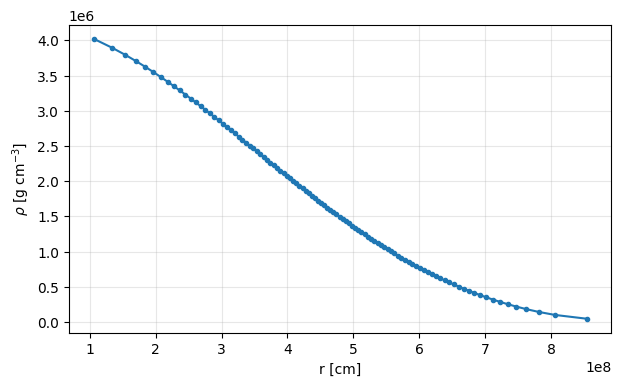

In [8]:
# Task 5
solution_1msun = white_dwarf_structure(n=100, mass_solar=1.0, radius_guess_solar=1.0, gamma=5/3)
print(solution_1msun["outer_radius_solar"], solution_1msun["info"])
table_1msun = structure_table(solution_1msun)
display(table_1msun)
plot_density_profile(solution_1msun)

In [9]:
# check whether M^(1/3) R is approximately constant.
masses_non_rel = [0.4, 0.6, 0.8, 1.0, 1.2]
scan_non_rel = radius_mass_scan(masses_non_rel, n=100, radius_guess_solar=1.0, gamma=5/3)
display(scan_non_rel)
print("mean constant =", np.mean([row["M13_R"] for row in scan_non_rel]))

[{'M_Msun': 0.4,
  'R_Rsun': np.float64(0.01655421502656353),
  'M13_R': np.float64(0.01219724991862521),
  'converged': True,
  'iterations': 17,
  'final_residual': np.float64(1.1678700515517143e-12)},
 {'M_Msun': 0.6,
  'R_Rsun': np.float64(0.014461438856241281),
  'M13_R': np.float64(0.012197249918617863),
  'converged': True,
  'iterations': 14,
  'final_residual': np.float64(1.6643184535198844e-08)},
 {'M_Msun': 0.8,
  'R_Rsun': np.float64(0.013139089173837363),
  'M13_R': np.float64(0.012197249918625211),
  'converged': np.True_,
  'iterations': 14,
  'final_residual': np.float64(1.2355456452484872e-12)},
 {'M_Msun': 1.0,
  'R_Rsun': np.float64(0.012197249918625216),
  'M13_R': np.float64(0.012197249918625216),
  'converged': True,
  'iterations': 13,
  'final_residual': np.float64(1.1117683485825156e-12)},
 {'M_Msun': 1.2,
  'R_Rsun': np.float64(0.011478051626633144),
  'M13_R': np.float64(0.012197249918562119),
  'converged': True,
  'iterations': 12,
  'final_residual': np.fl

mean constant = 0.012197249918611125


In [10]:
# near-relativistic gamma.
masses_rel = [1.41, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46]
scan_rel = radius_mass_scan(masses_rel, n=100, radius_guess_solar=1.0, gamma=1.334)
display(scan_rel)

[{'M_Msun': 1.41,
  'R_Rsun': np.float64(557.0364094974943),
  'M13_R': np.float64(624.630644593517),
  'converged': True,
  'iterations': 30,
  'final_residual': np.float64(7.008924086479899e-13)},
 {'M_Msun': 1.41,
  'R_Rsun': np.float64(557.0364094974943),
  'M13_R': np.float64(624.630644593517),
  'converged': True,
  'iterations': 30,
  'final_residual': np.float64(7.008924086479899e-13)},
 {'M_Msun': 1.42,
  'R_Rsun': np.float64(52.945544309980065),
  'M13_R': np.float64(59.510308126445345),
  'converged': True,
  'iterations': 29,
  'final_residual': np.float64(2.3244209507330402e-11)},
 {'M_Msun': 1.43,
  'R_Rsun': np.float64(5.1162012704470525),
  'M13_R': np.float64(5.764030900497044),
  'converged': True,
  'iterations': 34,
  'final_residual': np.float64(1.0564239348415014e-12)},
 {'M_Msun': 1.44,
  'R_Rsun': np.float64(0.5025024498687367),
  'M13_R': np.float64(0.5674474919129568),
  'converged': True,
  'iterations': 28,
  'final_residual': np.float64(1.0937726043332252e-

In [11]:
# compare with scipy.optimize.root.
# A closer radius guess can help scipy for the near-relativistic case.
scipy_non_rel = solve_with_scipy(n=100, mass_solar=1.0, radius_guess_solar=0.02, gamma=5/3)
scipy_rel = solve_with_scipy(n=100, mass_solar=1.42, radius_guess_solar=0.02, gamma=1.334)
print("gamma=5/3, M=1:   ", scipy_non_rel.r_solar[-1], scipy_non_rel.success)
print("gamma=1.334, M=1.42:", scipy_rel.r_solar[-1], scipy_rel.success)

gamma=5/3, M=1:    0.01219724991961144 True
gamma=1.334, M=1.42: 52.94554429358489 True
